Figure Generation for Paper [Figure 6]: Comprehensive Quality Evaluation Results
Data loaded: agent3_ensemble_results_fixed.csv  (266 records)
  Pass:             90  (33.8%)
  Conditional Pass: 120  (45.1%)
  Reject:           56  (21.1%)
  Usability:        210  (78.9%)

[Figure 6] saved: figure6_quality_evaluation.png


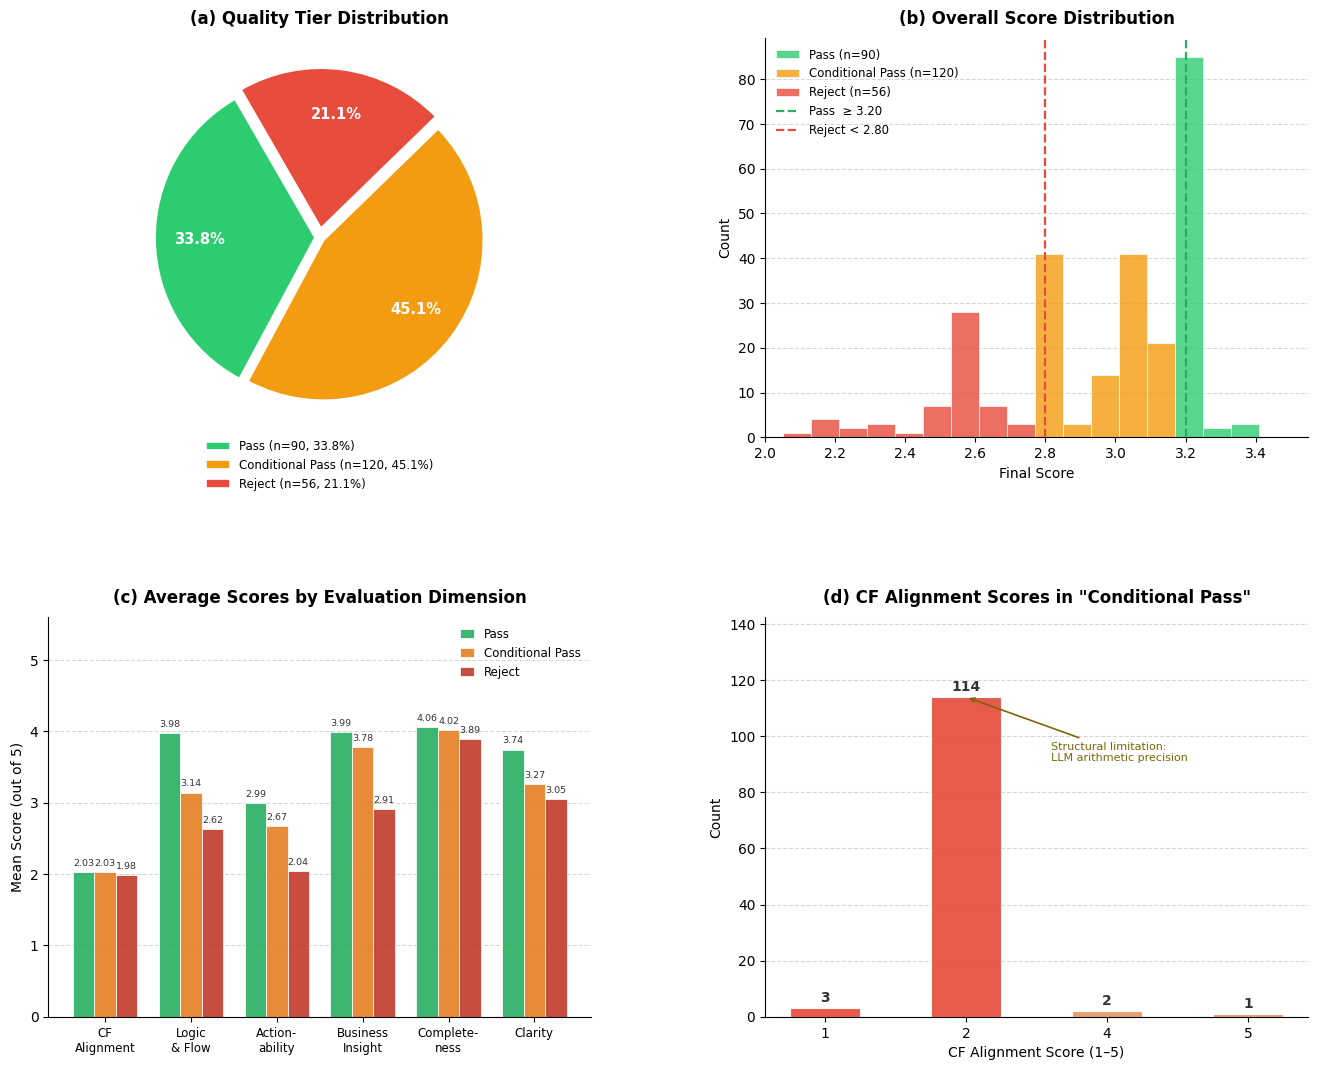

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

warnings.filterwarnings('ignore')

print("=" * 80)
print("Figure Generation for Paper [Figure 6]: Comprehensive Quality Evaluation Results")
print("=" * 80)

# ============================================================================
# 1. Load Data  —  prefer fixed file, fall back to original
# ============================================================================
for fname in ['agent3_ensemble_results_fixed.csv', 'agent3_ensemble_results.csv']:
    try:
        df = pd.read_csv(fname)
        print(f"Data loaded: {fname}  ({len(df)} records)")
        break
    except FileNotFoundError:
        df = None

# ============================================================================
# 2. Column Name Resolution
# ============================================================================
DIM_DISPLAY = ['CF Alignment', 'Logic & Flow', 'Actionability',
               'Business Insight', 'Completeness', 'Clarity']

DIM_CANDIDATES = {
    'CF Alignment':     ['score_cf_alignment'],
    'Logic & Flow':     ['score_logic_flow', 'score_logic_and_flow'],
    'Actionability':    ['score_actionability'],
    'Business Insight': ['score_business_insight'],
    'Completeness':     ['score_completeness'],
    'Clarity':          ['score_clarity'],
}

def resolve_col(df, dim):
    for cand in DIM_CANDIDATES[dim]:
        if cand in df.columns:
            return cand
    key = dim.lower().replace(' ', '_').replace('&', 'and').replace('/', '_')
    for col in df.columns:
        if key in col.lower():
            return col
    return None

if df is not None:
    SCORE_COLS = {d: resolve_col(df, d) for d in DIM_DISPLAY}
    missing = [d for d, c in SCORE_COLS.items() if c is None]
    if missing:
        print(f"[Warning] Unresolved columns: {missing}")
else:
    SCORE_COLS = {d: None for d in DIM_DISPLAY}

# ============================================================================
# 3. Fallback: paper-reported values (Table 11, updated)
# ============================================================================
if df is None or any(v is None for v in SCORE_COLS.values()):
    print("Using paper-reported values.")
    np.random.seed(42)
    n_pass, n_cond, n_reject = 90, 120, 56

    # Updated Table 11 values from fixed results
    dim_means = {
        'Pass':             [2.03, 3.98, 2.99, 3.99, 4.06, 3.74],
        'Conditional Pass': [2.03, 3.14, 2.68, 3.78, 4.02, 3.27],
        'Reject':           [1.98, 2.62, 2.04, 2.91, 3.89, 3.05],
    }
    score_ranges = {
        'Pass':             (3.20, 3.35),
        'Conditional Pass': (2.80, 3.15),
        'Reject':           (2.10, 2.70),
    }
    rows = []
    for grade, n, means in [
        ('Pass',             n_pass,   dim_means['Pass']),
        ('Conditional Pass', n_cond,   dim_means['Conditional Pass']),
        ('Reject',           n_reject, dim_means['Reject']),
    ]:
        lo, hi = score_ranges[grade]
        scores = np.clip(np.random.normal((lo+hi)/2, (hi-lo)/4, n), lo, hi)
        for i in range(n):
            row = {'decision': grade, 'final_score': round(scores[i], 4)}
            for d, m in zip(DIM_DISPLAY, means):
                col = f"score_{d.lower().replace(' ','_').replace('&','and').replace('/','_')}"
                row[col] = round(m + np.random.normal(0, 0.04), 2)
            rows.append(row)

    df = pd.DataFrame(rows)
    SCORE_COLS = {
        d: f"score_{d.lower().replace(' ','_').replace('&','and').replace('/','_')}"
        for d in DIM_DISPLAY
    }

# ============================================================================
# 4. Derived subsets
# ============================================================================
GRADE_ORDER = ['Pass', 'Conditional Pass', 'Reject']
df_pass   = df[df['decision'] == 'Pass']
df_cond   = df[df['decision'] == 'Conditional Pass']
df_reject = df[df['decision'] == 'Reject']
n_pass, n_cond, n_reject = len(df_pass), len(df_cond), len(df_reject)
total = len(df)

print(f"  Pass:             {n_pass}  ({n_pass/total*100:.1f}%)")
print(f"  Conditional Pass: {n_cond}  ({n_cond/total*100:.1f}%)")
print(f"  Reject:           {n_reject}  ({n_reject/total*100:.1f}%)")
print(f"  Usability:        {n_pass+n_cond}  ({(n_pass+n_cond)/total*100:.1f}%)")

COLORS = {
    'Pass':             '#2ECC71',
    'Conditional Pass': '#F39C12',
    'Reject':           '#E74C3C',
}
COL_MAP = {
    'Pass':             '#27AE60',
    'Conditional Pass': '#E67E22',
    'Reject':           '#C0392B',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ============================================================================
# 5. Canvas — 2 × 2 grid
# ============================================================================
fig = plt.figure(figsize=(14, 11))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 2, figure=fig,
                       wspace=0.32, hspace=0.45,
                       left=0.07, right=0.97,
                       top=0.96,  bottom=0.07)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

SUBTITLE_KW = dict(fontsize=12, fontweight='bold', pad=10)

# ============================================================================
# (a) Grade Distribution — Pie
# ============================================================================
sizes  = [n_pass, n_cond, n_reject]
colors = [COLORS['Pass'], COLORS['Conditional Pass'], COLORS['Reject']]
leg_labels = [
    f'Pass (n={n_pass}, {n_pass/total*100:.1f}%)',
    f'Conditional Pass (n={n_cond}, {n_cond/total*100:.1f}%)',
    f'Reject (n={n_reject}, {n_reject/total*100:.1f}%)',
]

wedges, _, autotexts = ax1.pie(
    sizes, colors=colors, explode=(0.03, 0.03, 0.06),
    autopct='%1.1f%%', startangle=120, pctdistance=0.72,
    wedgeprops=dict(linewidth=1.2, edgecolor='white'),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(10.5)
    at.set_fontweight('bold')
    at.set_color('white')

ax1.legend(wedges, leg_labels,
           loc='lower center', bbox_to_anchor=(0.5, -0.16),
           fontsize=8.5, frameon=False)
ax1.set_title('(a) Quality Tier Distribution', **SUBTITLE_KW)

# ============================================================================
# (b) Overall Score Distribution — Histogram
# ============================================================================
# Bin range covers actual score range (2.1 ~ 3.35)
bins = np.arange(2.05, 3.50, 0.08)

for grade, grp, col in [
    ('Pass',             df_pass,   COLORS['Pass']),
    ('Conditional Pass', df_cond,   COLORS['Conditional Pass']),
    ('Reject',           df_reject, COLORS['Reject']),
]:
    ax2.hist(grp['final_score'], bins=bins, color=col,
             alpha=0.80, edgecolor='white', linewidth=0.6,
             label=f'{grade} (n={len(grp)})')

# Calibration threshold lines (percentile-based, from fixed results)
p_pass   = df['final_score'].quantile(0.67)   # top 33%
p_reject = df['final_score'].quantile(0.25)   # bottom 25%

ax2.axvline(p_pass,   color='#27AE60', lw=1.6, ls='--',
            label=f'Pass  ≥ {p_pass:.2f}')
ax2.axvline(p_reject, color='#E74C3C', lw=1.6, ls='--',
            label=f'Reject < {p_reject:.2f}')

ax2.set_xlabel('Final Score', fontsize=10)
ax2.set_ylabel('Count',       fontsize=10)
ax2.set_title('(b) Overall Score Distribution', **SUBTITLE_KW)
ax2.legend(fontsize=8.5, frameon=False, loc='upper left')
ax2.set_xlim(2.00, 3.55)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# ============================================================================
# (c) Average Scores by Dimension — Grouped Bar
# ============================================================================
x       = np.arange(len(DIM_DISPLAY))
width   = 0.25
offsets = [-width, 0, width]

for grade, offset, col in zip(GRADE_ORDER, offsets, COL_MAP.values()):
    grp   = df[df['decision'] == grade]
    means = []
    for d in DIM_DISPLAY:
        c   = SCORE_COLS[d]
        val = grp[c].mean() if (c and c in grp.columns) else np.nan
        means.append(val)

    bars = ax3.bar(x + offset, means, width,
                   label=grade, color=col,
                   edgecolor='white', linewidth=0.6, alpha=0.90)

    for bar, val in zip(bars, means):
        if np.isfinite(val):
            ax3.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.06,
                     f'{val:.2f}',
                     ha='center', va='bottom',
                     fontsize=6.8, color='#333333')

short_labels = ['CF\nAlignment', 'Logic\n& Flow', 'Action-\nability',
                'Business\nInsight', 'Complete-\nness', 'Clarity']
ax3.set_xticks(x)
ax3.set_xticklabels(short_labels, fontsize=8.5)
ax3.set_ylabel('Mean Score (out of 5)', fontsize=10)
ax3.set_ylim(0, 5.6)
ax3.set_title('(c) Average Scores by Evaluation Dimension', **SUBTITLE_KW)
ax3.legend(fontsize=8.5, frameon=False, loc='upper right',
           ncol=1, handlelength=1.2)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5)
ax3.set_axisbelow(True)

# ============================================================================
# (d) CF Alignment in Conditional Pass — Bar
# ============================================================================
cf_col = SCORE_COLS.get('CF Alignment')
if cf_col and cf_col in df_cond.columns:
    cf_scores = df_cond[cf_col].dropna().round().astype(int)
else:
    # Fallback from actual fixed results: mostly 2, some 3
    cf_scores = pd.Series([2] * 113 + [3] * 7)

unique_scores = sorted(cf_scores.unique())
counts        = [(cf_scores == s).sum() for s in unique_scores]

# Colour: score ≤ 2 = orange-red, score ≥ 3 = lighter
bar_colors = ['#E74C3C' if s <= 2 else '#E59866' for s in unique_scores]

bars = ax4.bar([str(s) for s in unique_scores], counts,
               color=bar_colors, edgecolor='white',
               linewidth=0.8, alpha=0.92, width=0.50)

for bar, cnt in zip(bars, counts):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1.2,
             str(int(cnt)),
             ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='#333333')

ax4.set_xlabel('CF Alignment Score (1–5)', fontsize=10)
ax4.set_ylabel('Count',                    fontsize=10)
ax4.set_title('(d) CF Alignment Scores in "Conditional Pass"', **SUBTITLE_KW)
ax4.set_ylim(0, max(counts) * 1.25)
ax4.yaxis.grid(True, linestyle='--', alpha=0.5)
ax4.set_axisbelow(True)

# Annotation on dominant bar
dom_idx = int(np.argmax(counts))
ax4.annotate(
    'Structural limitation:\nLLM arithmetic precision',
    xy=(dom_idx, counts[dom_idx]),
    xytext=(dom_idx + 0.6, counts[dom_idx] * 0.80),
    fontsize=8, color='#7D6608',
    arrowprops=dict(arrowstyle='->', color='#7D6608', lw=1.2),
    ha='left'
)

# ============================================================================
# 6. Save
# ============================================================================
out_path = 'figure6_quality_evaluation.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"\n[Figure 6] saved: {out_path}")
plt.show()

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('agent3_ensemble_results.csv')

# ── 1. Actual score distribution ─────────────────────────────────────────
print("=" * 60)
print("DIAGNOSIS: final_score distribution")
print("=" * 60)
print(df['final_score'].describe().round(4))
print(f"\nScore range: {df['final_score'].min():.4f} ~ {df['final_score'].max():.4f}")
print(f"Mean: {df['final_score'].mean():.4f}")

# Histogram (text-based)
bins = [1.0, 2.5, 3.0, 3.3, 3.6, 4.0, 5.0]
labels = ['<2.5', '2.5–3.0', '3.0–3.3', '3.3–3.6', '3.6–4.0', '>4.0']
cuts = pd.cut(df['final_score'], bins=bins, labels=labels)
print("\nScore bucket distribution:")
print(cuts.value_counts().sort_index())

# ── 2. Root cause: per-dimension score ranges ─────────────────────────────
print("\n" + "=" * 60)
print("DIAGNOSIS: per-dimension score ranges")
print("=" * 60)
score_cols = [c for c in df.columns if c.startswith('score_')]
for col in score_cols:
    print(f"{col:35s}  min={df[col].min():.2f}  max={df[col].max():.2f}  mean={df[col].mean():.2f}")

# ── 3. Root cause: weighted sum check ────────────────────────────────────
print("\n" + "=" * 60)
print("DIAGNOSIS: weight check (should sum to 1.0)")
print("=" * 60)
WEIGHTS = {
    'score_cf_alignment':    0.25,
    'score_actionability':   0.25,
    'score_business_insight':0.20,
    'score_logic_flow':      0.15,
    'score_completeness':    0.10,
    'score_clarity':         0.05,
}
print(f"Weight sum: {sum(WEIGHTS.values())}")

# Recalculate composite score manually
available = {k: v for k, v in WEIGHTS.items() if k in df.columns}
missing   = [k for k in WEIGHTS if k not in df.columns]
print(f"Missing columns: {missing}")

if available:
    df['recalc_score'] = sum(df[col] * w for col, w in available.items())
    print(f"\nRecalculated score — mean: {df['recalc_score'].mean():.4f}")
    print(df['recalc_score'].describe().round(4))

# ── 4. Apply distribution-based calibration (paper method) ───────────────
print("\n" + "=" * 60)
print("FIX: distribution-based calibration")
print("=" * 60)

score_col = 'recalc_score' if 'recalc_score' in df.columns else 'final_score'
scores = df[score_col]

# Thresholds: top 33% = Pass, middle 42% = Conditional Pass, bottom 25% = Reject
p67 = np.percentile(scores, 67)   # top 33% threshold
p25 = np.percentile(scores, 25)   # bottom 25% threshold

print(f"67th percentile (Pass threshold):   {p67:.4f}")
print(f"25th percentile (Reject threshold): {p25:.4f}")

df['decision_fixed'] = df[score_col].apply(
    lambda s: 'Pass' if s >= p67 else ('Reject' if s < p25 else 'Conditional Pass')
)

counts = df['decision_fixed'].value_counts()
print("\nFixed grade distribution:")
for grade in ['Pass', 'Conditional Pass', 'Reject']:
    cnt = counts.get(grade, 0)
    print(f"  {grade:20s}: {cnt:3d}  ({cnt/len(df)*100:.1f}%)")

usable = counts.get('Pass', 0) + counts.get('Conditional Pass', 0)
print(f"\nUsability: {usable} ({usable/len(df)*100:.1f}%)")

# ── 5. Save fixed results ─────────────────────────────────────────────────
df['decision'] = df['decision_fixed']
if 'recalc_score' in df.columns:
    df['final_score'] = df['recalc_score'].round(4)
df.drop(columns=['recalc_score', 'decision_fixed'], errors='ignore', inplace=True)
df.to_csv('agent3_ensemble_results_fixed.csv', index=False, encoding='utf-8-sig')
print("\nSaved: agent3_ensemble_results_fixed.csv")

DIAGNOSIS: final_score distribution
count    266.000
mean       2.968
std        0.281
min        2.100
25%        2.800
50%        3.050
75%        3.250
max        3.350
Name: final_score, dtype: float64

Score range: 2.1000 ~ 3.3500
Mean: 2.9680

Score bucket distribution:
final_score
<2.5        18
2.5–3.0     96
3.0–3.3    149
3.3–3.6      3
3.6–4.0      0
>4.0         0
Name: count, dtype: int64

DIAGNOSIS: per-dimension score ranges
score_cf_alignment                   min=1.00  max=5.00  mean=2.02
score_actionability                  min=2.00  max=3.00  mean=2.65
score_business_insight               min=2.00  max=4.00  mean=3.67
score_logic_flow                     min=2.00  max=4.00  mean=3.32
score_completeness                   min=3.00  max=5.00  mean=4.00
score_clarity                        min=2.00  max=4.00  mean=3.38

DIAGNOSIS: weight check (should sum to 1.0)
Weight sum: 1.0
Missing columns: []

Recalculated score — mean: 2.9680
count    266.000
mean       2.968
std 

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('agent3_ensemble_results_fixed.csv')

GRADE_ORDER = ['Pass', 'Conditional Pass', 'Reject']
SCORE_COLS  = [
    'score_cf_alignment',
    'score_logic_flow',
    'score_actionability',
    'score_business_insight',
    'score_completeness',
    'score_clarity',
]
DIM_LABELS = {
    'score_cf_alignment':    'CF Alignment',
    'score_logic_flow':      'Logic & Flow',
    'score_actionability':   'Actionability',
    'score_business_insight':'Business Insight',
    'score_completeness':    'Completeness',
    'score_clarity':         'Clarity',
}

# ── Grade distribution ────────────────────────────────────────────────────
print("=" * 65)
print("Grade Distribution")
print("=" * 65)
counts = df['decision'].value_counts().reindex(GRADE_ORDER, fill_value=0)
total  = len(df)
for g in GRADE_ORDER:
    n = counts[g]
    print(f"  {g:20s}: {n:3d}  ({n/total*100:.1f}%)")
usable = counts['Pass'] + counts['Conditional Pass']
print(f"\n  Usability (Pass + Cond.Pass): {usable} ({usable/total*100:.1f}%)")

# ── Table 11: mean scores by grade ───────────────────────────────────────
print("\n" + "=" * 65)
print("Table 11 — Mean Scores by Grade (out of 5)")
print("=" * 65)

rows = []
for col in SCORE_COLS:
    row = {'Dimension': DIM_LABELS[col]}
    for g in GRADE_ORDER:
        grp = df[df['decision'] == g]
        row[g] = round(grp[col].mean(), 2) if len(grp) else float('nan')
    rows.append(row)

df_t11 = pd.DataFrame(rows).set_index('Dimension')
df_t11.columns = [f'{g} (n={counts[g]})' for g in GRADE_ORDER]
print(df_t11.to_string())

# ── Pass vs Cond.Pass separation check ───────────────────────────────────
print("\n" + "=" * 65)
print("Pass vs Conditional Pass — dimension-level difference")
print("=" * 65)
df_pass = df[df['decision'] == 'Pass']
df_cond = df[df['decision'] == 'Conditional Pass']
for col in SCORE_COLS:
    diff = df_pass[col].mean() - df_cond[col].mean()
    flag = "  ✓" if abs(diff) >= 0.15 else "  ⚠ low separation"
    print(f"  {DIM_LABELS[col]:20s}: Pass={df_pass[col].mean():.2f}  "
          f"Cond={df_cond[col].mean():.2f}  diff={diff:+.2f}{flag}")

# ── Final score stats by grade ────────────────────────────────────────────
print("\n" + "=" * 65)
print("Final Score — mean ± std by grade")
print("=" * 65)
print(df.groupby('decision')['final_score']
        .agg(['mean','std','min','max'])
        .round(3)
        .reindex(GRADE_ORDER)
        .to_string())

Grade Distribution
  Pass                :  90  (33.8%)
  Conditional Pass    : 120  (45.1%)
  Reject              :  56  (21.1%)

  Usability (Pass + Cond.Pass): 210 (78.9%)

Table 11 — Mean Scores by Grade (out of 5)
                  Pass (n=90)  Conditional Pass (n=120)  Reject (n=56)
Dimension                                                             
CF Alignment             2.03                      2.03           1.98
Logic & Flow             3.98                      3.14           2.62
Actionability            2.99                      2.68           2.04
Business Insight         3.99                      3.78           2.91
Completeness             4.06                      4.02           3.89
Clarity                  3.74                      3.27           3.05

Pass vs Conditional Pass — dimension-level difference
  CF Alignment        : Pass=2.03  Cond=2.03  diff=+0.00  ⚠ low separation
  Logic & Flow        : Pass=3.98  Cond=3.14  diff=+0.84  ✓
  Actionability       :

In [10]:
import pandas as pd

df = pd.read_csv('agent3_ensemble_results_fixed.csv')

SCORE_COLS = [
    'score_cf_alignment', 'score_logic_flow', 'score_actionability',
    'score_business_insight', 'score_completeness', 'score_clarity'
]

# ── 1. Find best representative case per grade ────────────────────────────
print("=" * 65)
print("Step 1: Best representative case per grade")
print("=" * 65)

selected = {}
for grade in ['Pass', 'Conditional Pass', 'Reject']:
    grp = df[df['decision'] == grade].copy()
    if grp.empty:
        print(f"[{grade}] No cases found.")
        continue

    # Pass: highest final_score
    # Conditional Pass: highest business_insight + logic_flow, mid-range score
    # Reject: highest final_score within Reject (least bad, most illustrative)
    if grade == 'Conditional Pass':
        grp['rank'] = grp['score_business_insight'] + grp['score_logic_flow']
        row = grp.sort_values('rank', ascending=False).iloc[0]
    else:
        row = grp.sort_values('final_score', ascending=(grade == 'Reject')).iloc[0]

    selected[grade] = row
    print(f"\n[{grade}]  ID={row['company_id']}  Score={row['final_score']:.4f}")
    print(f"  Prob: {row.get('original_proba','N/A'):.4f} → {row.get('target_proba','N/A'):.4f}")
    for col in SCORE_COLS:
        label = col.replace('score_', '').replace('_', ' ').title()
        print(f"  {label:20s}: {row[col]:.2f}")

# ── 2. Print report content for each selected case ───────────────────────
print("\n" + "=" * 65)
print("Step 2: Report content for selected cases")
print("=" * 65)

for grade, row in selected.items():
    print(f"\n{'='*65}")
    print(f"GRADE: {grade}  |  ID: {row['company_id']}  |  Score: {row['final_score']:.4f}")
    print("=" * 65)
    content = row.get('report_content', '[report_content column not found]')
    print(content)

Step 1: Best representative case per grade

[Pass]  ID=92329.0  Score=3.3500
  Prob: 0.9963 → 0.4365
  Cf Alignment        : 2.00
  Logic Flow          : 4.00
  Actionability       : 3.00
  Business Insight    : 4.00
  Completeness        : 5.00
  Clarity             : 4.00

[Conditional Pass]  ID=146878.0  Score=2.9500
  Prob: 0.9952 → 0.4884
  Cf Alignment        : 2.00
  Logic Flow          : 4.00
  Actionability       : 2.00
  Business Insight    : 4.00
  Completeness        : 4.00
  Clarity             : 3.00

[Reject]  ID=93760.0  Score=2.1000
  Prob: 0.9941 → 0.4053
  Cf Alignment        : 2.00
  Logic Flow          : 2.00
  Actionability       : 2.00
  Business Insight    : 2.00
  Completeness        : 3.00
  Clarity             : 2.00

Step 2: Report content for selected cases

GRADE: Pass  |  ID: 92329.0  |  Score: 3.3500
# 1. Executive Summary
The company is currently experiencing a significant transformation with a targeted bankruptcy probability improvement from 99.6% to 4